In [71]:
! pip install numpy
! pip install matplotlib
! pip install pandas

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

In [304]:
# read science data line by line, parse json, and store in a list
# filename = 'batch_20240411_1440_MITMBA.scienceData.jsonl'
# filename = 'batch_20240416_1753_MITMBA.scienceData.jsonl'
filenames = [
    "batch_20240411_1440_MITMBA.scienceData.jsonl",
    "batch_20240416_1753_MITMBA.scienceData.jsonl"
]
data = []
for filename in filenames:
    with open(filename) as f:
        for line in f:
            parsed = json.loads(line)
            if parsed['sampleId'] != 'missing':
                data.append(parsed)

sorted_data = sorted(data, key=lambda x: x['treatment']['name']+x['gameId'])

new_data = []
game_lookups = {}
game_index = 0
for i, row in enumerate(sorted_data):
    row["player"] = i
    if row["gameId"] not in game_lookups:
        game_lookups[row["gameId"]] = game_index
        row["game"] = game_index
        game_index += 1
    else:
        row["game"] = game_lookups[row["gameId"]]

    new_data.append(row)

data = new_data
index = pd.MultiIndex.from_tuples([(row['treatment']["name"], row['game'], row['player']) for row in data], names=['treatment', 'game', 'player'])
len(data)

24

In [287]:
print(list(data[0].keys()))

['containerTag', 'deliberationId', 'sampleId', 'browserInfo', 'connectionInfo', 'batchId', 'config', 'timeBatchInitialized', 'timeArrived', 'timeEnteredCountdown', 'timeIntroDone', 'timeStarted', 'timeComplete', 'consent', 'introSequence', 'gameId', 'treatment', 'position', 'recordingsFolder', 'recordingRoomName', 'recordingsPath', 'recordingIds', 'surveys', 'prompts', 'qualtrics', 'stageSubmissions', 'QCSurvey', 'exitStatus', 'connectionHistory', 'speakerEvents', 'reports', 'checkIns', 'textChats', 'cumulativeSpeakingTime', 'exportErrors', 'player', 'game']


In [305]:
treatments = pd.DataFrame([row["treatment"]["name"] for row in data], columns=["treatment"], index=index)
treatments

treatment
treatment game player           
nonschema 0    0       nonschema
               1       nonschema
          1    2       nonschema
               3       nonschema
          2    4       nonschema
               5       nonschema
          3    6       nonschema
               7       nonschema
          4    8       nonschema
               9       nonschema
schema    5    10         schema
               11         schema
          6    12         schema
               13         schema
          7    14         schema
               15         schema
          8    16         schema
               17         schema
          9    18         schema
               19         schema
          10   20         schema
               21         schema
          11   22         schema
               23         schema

In [306]:
connection_info = pd.DataFrame([row['connectionInfo'] for row in data], index=index)
connection_info

country          timezone  isKnownVpn timezoneOffset  \
treatment game player                                                        
nonschema 0    0           US   America/Chicago       False         -05:00   
               1           US   America/Chicago       False         -05:00   
          1    2           US  America/New_York       False         -04:00   
               3           US  America/New_York       False         -04:00   
          2    4           US  America/New_York       False         -04:00   
               5           US  America/New_York       False         -04:00   
          3    6           US  America/New_York       False         -04:00   
               7           US  America/New_York       False         -04:00   
          4    8           US  America/New_York       False         -04:00   
               9           US  America/New_York       False         -04:00   
schema    5    10          US  America/New_York       False         -04:00   
               11          US  America/New_York       False         -04:00   
          6    12          US  America/New_York       False         -04:00   
               13          US  America/New_York       False         -04:00   
          7    14          US  America/New_York       False         -04:00   
               15          US  America/New_York       False         -04:00   
          8    16          US  America/New_York       False         -04:00   
               17          US  America/New_York       False         -04:00   
          9    18          US  America/New_York       False         -04:00   
               19          US  America/New_York       False         -04:00   
          10   20          US  America/New_York       False         -04:00   
               21          US  America/New_York       False         -04:00   
          11   22          US  America/New_York       False         -04:00   
               23          US  America/New_York       False         -04:00   

                       isLikelyVpn  
treatment game player               
nonschema 0    0              True  
               1              True  
          1    2             False  
               3             False  
          2    4             False  
               5             False  
          3    6             False  
               7             False  
          4    8             False  
               9             False  
schema    5    10            False  
               11            False  
          6    12            False  
               13            False  
          7    14            False  
               15            False  
          8    16            False  
               17            False  
          9    18            False  
               19            False  
          10   20            False  
               21            False  
          11   22            False  
               23            False

In [307]:
connection_info['country'].value_counts()

country
US    24
Name: count, dtype: int64

In [308]:
browser_info = pd.DataFrame([row['browserInfo'] for row in data], index=index)
browser_info

width  height  \
treatment game player                  
nonschema 0    0        1470     854   
               1        1440     875   
          1    2        1470     860   
               3        1470     824   
          2    4        1493     885   
               5        1280     672   
          3    6        1280     672   
               7        1470     854   
          4    8        1470     919   
               9        1512     884   
schema    5    10       1512     950   
               11       1920    1032   
          6    12       1440     821   
               13       2560    1355   
          7    14       1280     672   
               15       1470     919   
          8    16       1470     857   
               17       1920    1232   
          9    18       1470     850   
               19       1280     752   
          10   20       1470     857   
               21       1280     752   
          11   22       1368     888   
               23       1920    1055   

                                                               userAgent  \
treatment game player                                                      
nonschema 0    0       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
               1       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
          1    2       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
               3       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
          2    4       Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...   
               5       Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...   
          3    6       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
               7       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
          4    8       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
               9       Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
schema    5    10      Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
               11      Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
          6    12      Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
               13      Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
          7    14      Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
               15      Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
          8    16      Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
               17      Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
          9    18      Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
               19      Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
          10   20      Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   
               21      Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
          11   22      Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
               23      Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...   

                      language          timezone  
treatment game player                             
nonschema 0    0         en-US  America/New_York  
               1         en-US  America/New_York  
          1    2         en-US  America/New_York  
               3         en-US  America/New_York  
          2    4         en-US  America/New_York  
               5         en-US  America/New_York  
          3    6         en-US  America/New_York  
               7         en-US  America/New_York  
          4    8         en-US  America/New_York  
               9            en  America/New_York  
schema    5    10        en-US  America/New_York  
               11        en-US  America/New_York  
          6    12        en-US  America/New_York  
               13        en-US  America/New_York  
          7    14        ko-KR  America/New_York  
               15        en-US  America/New_York  
          8    16        en-US  America/New_York  
               17        es-ES  Amer

In [309]:
QC = pd.DataFrame([(row['QCSurvey']['responses'] if row['QCSurvey'] != "missing" else {}) for row in data], index=index)
QC

technicalProblems joiningProblems  videoQuality  \
treatment game player                                                   
nonschema 0    0                     no              no           5.0   
               1                     no              no           5.0   
          1    2                    NaN             NaN           NaN   
               3                     no              no           3.0   
          2    4                     no              no           5.0   
               5                     no              no           4.0   
          3    6                     no              no           4.0   
               7                     no              no           4.0   
          4    8                    NaN             NaN           NaN   
               9                    NaN             NaN           NaN   
schema    5    10                    no              no           5.0   
               11                    no              no           4.0   
          6    12                    no              no           4.0   
               13                    no              no           5.0   
          7    14                   NaN             NaN           NaN   
               15                    no              no           5.0   
          8    16                   NaN             NaN           NaN   
               17                    no              no           5.0   
          9    18                    no              no           5.0   
               19                    no              no           4.0   
          10   20                    no              no           5.0   
               21                    no              no           5.0   
          11   22                    no              no           5.0   
               23                   NaN             NaN           NaN   

                       clearInstructions adequateTime adequateCompensation  \
treatment game player                                                        
nonschema 0    0                     5.0     adequate                  N/A   
               1                     4.0     too_much                  N/A   
          1    2                     NaN          NaN                  NaN   
               3                     2.0     too_much                  N/A   
          2    4                     4.0     adequate                  N/A   
               5                     4.0     adequate                  N/A   
          3    6                     5.0     adequate            underpaid   
               7                     5.0     too_much                  N/A   
          4    8                     NaN          NaN                  NaN   
               9                     NaN          NaN                  NaN   
schema    5    10                    5.0     too_much            underpaid   
               11                    4.0     adequate                  N/A   
          6    12                    4.0     adequate                  N/A   
               13                    4.0     adequate                  N/A   
          7    14                    NaN          NaN                  NaN   
               15                    5.0     adequate                  N/A   
          8    16                    NaN          NaN                  NaN   
               17                    4.0     adequate          fairly_paid   
          9    18                    4.0     adequate                  N/A   
               19                    4.0     adequate          fairly_paid   
          10   20                    4.0     too_much                  N/A   
               21                    5.0     adequate                  N/A   
          11   22                    5.0     adequate                  N/A   
               23                    NaN          NaN                  NaN   

                      participateAgain  \
treatment game player                    
nonschema 

In [310]:
for i, row in QC.iterrows():
    print(row["textExpansion"])

nan
When others joined, I did not have a chance to review the initial instructions. 
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
cool simulation
nan
nan
nan
nan


In [311]:
demographics = pd.DataFrame([(row["surveys"]["survey_Demographics_unknown_postIntro"]["responses"] if "survey_Demographics_unknown_postIntro" in row["surveys"] else {}) for row in data], index=index)
demographics

birth_year language_primary  english_written  \
treatment game player                                                
nonschema 0    0            1997          Chinese                5   
               1            1980         Japanese                4   
          1    2            1995          English                5   
               3            1997             Thai                4   
          2    4            1989          Spanish                4   
               5            1983          English                5   
          3    6            1995          English                5   
               7            1996          English                5   
          4    8            1998          English                5   
               9            1998          Spanish                5   
schema    5    10           1994          English                5   
               11           1991          English                5   
          6    12           1999          English                5   
               13           1984          English                5   
          7    14           1992          English                5   
               15           1995          English                5   
          8    16           1996          English                5   
               17           1995          Spanish                4   
          9    18           1996          English                5   
               19           1984          English                5   
          10   20           1994          English                5   
               21           1990          English                5   
          11   22           1995          English                5   
               23           1995          English                5   

                       english_spoken employment_status country_reside  \
treatment game player                                                    
nonschema 0    0                    5         A student  United States   
               1                    4         A student  United States   
          1    2                    5         A student  United States   
               3                    4         A student  United States   
          2    4                    4         A student  United States   
               5                    5           Retired  United States   
          3    6                    5         A student  United States   
               7                    5         A student  United States   
          4    8                    5         A student  United States   
               9                    5         A student  United States   
schema    5    10                   5         A student  United States   
               11                   5         A student  United States   
          6    12                   5         A student  United States   
               13                   5         A student  United States   
          7    14                   5         A student  United States   
               15                   5         A student  United States   
          8    16                   5         A student  United States   
               17                   4         A student  United States   
          9    18                   5         A student  United States   
               19                   5         A student  United States   
          10   20                   5         A student  United States   
               21                   5         A student  United States   
          11   22                   5         A student  United States   
               23                   5         A student  United States   

                       gender education_US latin_US  \
treatment game player                                 
nonschema 0    0       female            6       No   
               1         male            6       No   
          1    2       female            7       No   
 

In [312]:
submit_times = pd.DataFrame([{k: v['time'] for k, v in row['stageSubmissions'].items()} for row in data], index=index)
submit_times

submitButton_labeling_1  submitButton_recall_1_1  \
treatment game player                                                     
nonschema 0    0                       307.863                    6.196   
               1                       308.037                    4.814   
          1    2                       333.460                    4.679   
               3                       333.754                    7.783   
          2    4                       176.277                    6.810   
               5                       175.767                    5.241   
          3    6                       246.319                    8.106   
               7                       247.060                   13.768   
          4    8                       269.783                    2.437   
               9                       271.326                    5.950   
schema    5    10                      250.370                    5.955   
               11                      250.801                   18.390   
          6    12                      198.421                   10.058   
               13                      198.716                    7.163   
          7    14                      150.224                    8.658   
               15                      149.457                    7.914   
          8    16                      154.935                    6.906   
               17                      155.154                    6.137   
          9    18                      531.594                   14.376   
               19                      532.769                   24.321   
          10   20                      159.653                    8.412   
               21                      169.899                   10.613   
          11   22                      245.455                   21.044   
               23                      275.292                      NaN   

                       submitButton_recall_1_2  submitButton_recall_1_4  \
treatment game player                                                     
nonschema 0    0                         3.795                    5.666   
               1                         3.026                    3.884   
          1    2                         3.442                    2.876   
               3                         3.696                    1.928   
          2    4                         5.630                    4.828   
               5                         4.149                    4.361   
          3    6                         3.254                    6.328   
               7                         5.905                    3.997   
          4    8                         4.659                    3.087   
               9                         4.162                    3.590   
schema    5    10                       10.253                    9.595   
               11                       10.695                    8.063   
          6    12                        8.227                    4.565   
               13                       11.343                    6.679   
          7    14                        7.074                    5.988   
               15                        5.350                    5.298   
          8    16                       15.495                    5.175   
               17                        5.699                    7.437   
          9    18                       19.188                   18.304   
               19                       24.357                   17.480   
          10   20                        4.207                    6.103   
               21                        9.395                    7.979   
          11   22                       14.457                    9.494   
               23                       25.263                   10.332   

                       submitButton_labeling_2  submitButton_recall_2_1  \
treatment game player                         

Text(0.5, 1.0, 'Average time spent on labeling stages')

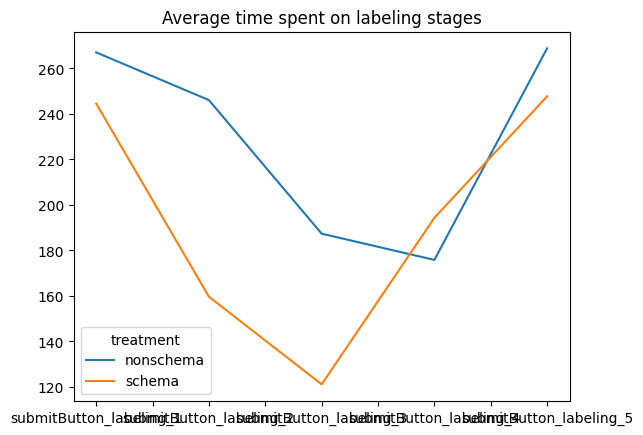

In [326]:
submit_times[labeling_stages].groupby(level='treatment').mean().T.plot()
plt.title("Average time spent on labeling stages")

Text(0.5, 1.0, 'Time to coordinate labels')

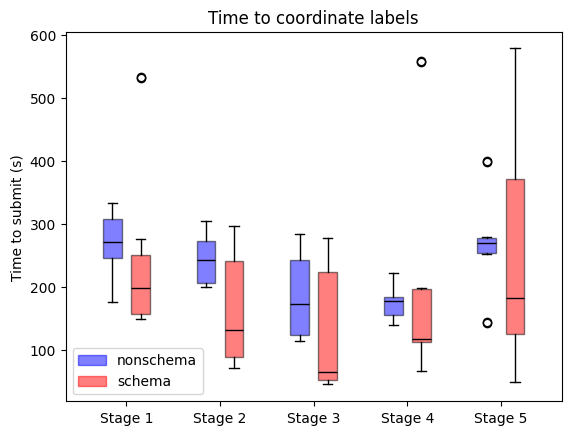

In [364]:
plt.boxplot(submit_times[labeling_stages].loc["nonschema"].fillna(600), positions=np.arange(0, len(labeling_stages))-.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='blue', alpha=.5), medianprops=dict(color='black'))
plt.boxplot(submit_times[labeling_stages].loc["schema"].fillna(600), positions=np.arange(0, len(labeling_stages))+.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='red', alpha=.5), medianprops=dict(color='black'))
plt.xticks(range(len(labeling_stages)),[re.sub(r'submitButton_labeling_', 'Stage ', label) for label in labeling_stages])

import matplotlib.patches as mpatches

blue_patch = mpatches.Patch(color='blue', alpha=.5, label='nonschema')
red_patch = mpatches.Patch(color='red', alpha=.5, label='schema')

plt.legend(handles=[blue_patch, red_patch])
plt.ylabel('Time to submit (s)')
plt.title("Time to coordinate labels")


Text(0.5, 1.0, 'Time to coordinate labels')

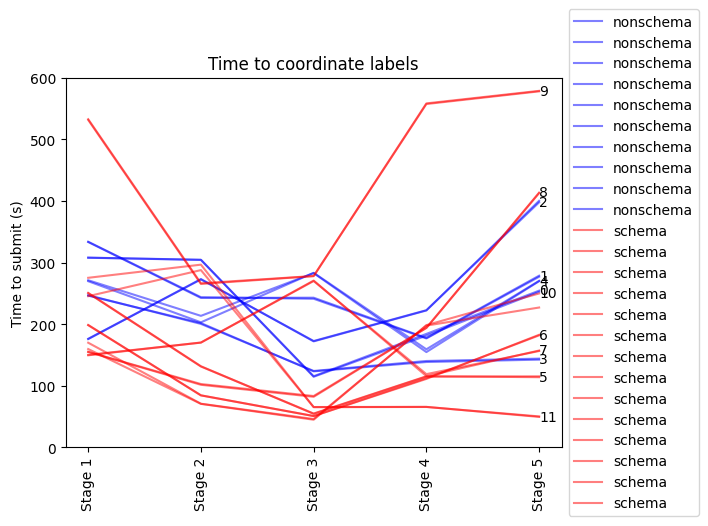

In [313]:
labeling_stages = [label for label in submit_times.columns if 'labeling' in label]

for i, row in submit_times.iterrows():
    plt.plot(row[labeling_stages], c=('blue' if i[0] == 'nonschema' else 'red'), alpha=0.5, label=f"{i[0]}")
    if i[2] % 2 == 0:
        plt.annotate(
            f"{i[1]}", (len(labeling_stages)-1, row[labeling_stages[-1]]), 
            xycoords="data", ha='left', va='center'
            )

plt.xticks(rotation=90)
plt.ylim(0, 600)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.xticks(range(len(labeling_stages)),[re.sub(r'submitButton_labeling_', 'Stage ', label) for label in labeling_stages])
plt.ylabel('Time to submit (s)')
plt.title("Time to coordinate labels")

Text(0.5, 1.0, 'Time to recall labels')

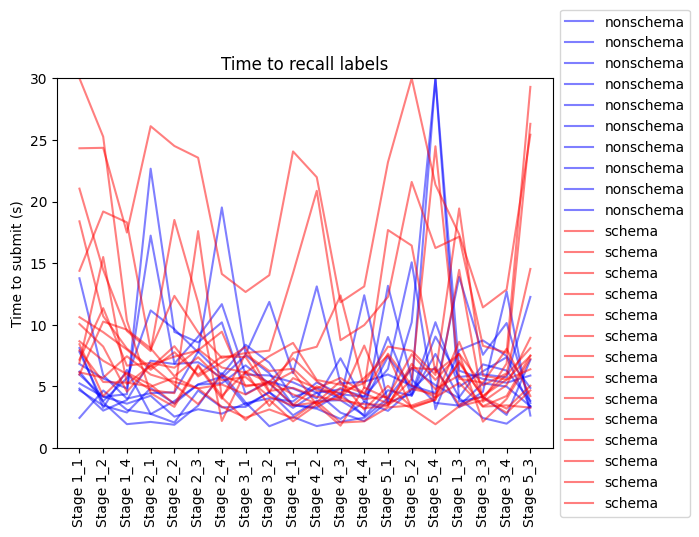

In [314]:
recall_stages = [label for label in submit_times.columns if 'recall' in label]

for i, row in submit_times.iterrows():
    plt.plot(row[recall_stages].fillna(30), c=('blue' if i[0] == 'nonschema' else 'red'), alpha=0.5, label=f"{i[0]}")

plt.xticks(rotation=90)
plt.ylim(0, 30)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.xticks(range(len(recall_stages)),[re.sub(r'submitButton_recall_', 'Stage ', label) for label in recall_stages])
plt.ylabel('Time to submit (s)')
plt.title("Time to recall labels")

Text(0.5, 1.0, 'Time to recall labels')

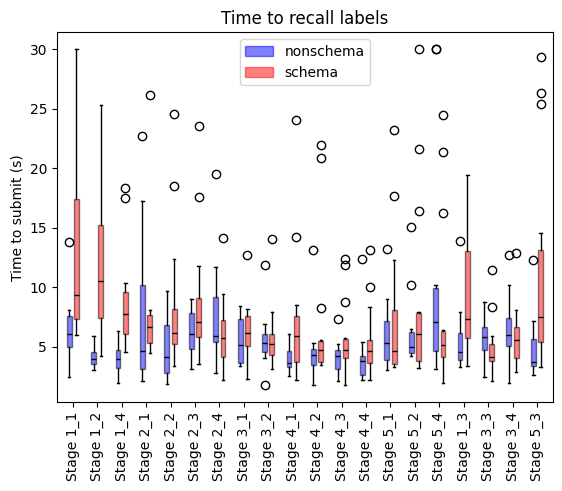

In [365]:
plt.boxplot(submit_times[recall_stages].loc["nonschema"].fillna(30), positions=np.arange(0, len(recall_stages))-.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='blue', alpha=.5), medianprops=dict(color='black'))
plt.boxplot(submit_times[recall_stages].loc["schema"].fillna(30), positions=np.arange(0, len(recall_stages))+.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='red', alpha=.5), medianprops=dict(color='black'))
plt.xticks(range(len(recall_stages)),[re.sub(r'submitButton_recall_', 'Stage ', label) for label in recall_stages], rotation=90)

import matplotlib.patches as mpatches

blue_patch = mpatches.Patch(color='blue', alpha=.5, label='nonschema')
red_patch = mpatches.Patch(color='red', alpha=.5, label='schema')

plt.legend(handles=[blue_patch, red_patch])
plt.ylabel('Time to submit (s)')
plt.title("Time to recall labels")

In [315]:
print(data[0]['prompts']['prompt_labeling_2']['value'])

Image 1: red right grey
Image 2: red right white
Image 3: red left white
Image 4: yellow left white
Image 5: yellow right white
Image 6: yellow left grey
Image 7: yellow right grey
Image 8: red left grey



In [316]:
def extract_word(cell):
    return str(re.sub(r"\d", "", str(cell).replace("Image", "")).replace(":", "").strip().lower())
    # return str(cell).split(":")[1].strip().lower()

    # pattern = r"Image \d+:\s*(\w+\s)\s*"
    # match = re.search(pattern, str(cell), re.IGNORECASE)
    # return match.group(1) if match else cell

labels_collector = []
for row in data:
    row_labels = {}
    for key, d in row['prompts'].items():
        if 'labeling' in key:
            round = key.split('_')[2]
            round_labels = [extract_word(line) for line in d['value'].split("\n") if len(line.strip()) > 0]
            for i, label in enumerate(round_labels):
                row_labels[(round, i+1)] = label
    labels_collector.append(row_labels)
labels = pd.DataFrame(labels_collector, index=index).T
labels.index = pd.MultiIndex.from_tuples(labels.index, names=['round', 'image'])
labels = labels.T.groupby(level=["treatment", "game"]).first().T
labels

treatment             nonschema                            \
game                         0         1               2    
round image                                                 
1     1                     dog   eyeball         one eye   
      2                       t   octopus               t   
      3                    tube    spiral            ring   
      4                    crab      wide           train   
      5                  shorty    wall-e          wallee   
      6                   board    square  sheet of paper   
      7                     eye       uno          webcam   
      8                big foot     robot     caterpillar   
2     1          red right grey   bigfeet     red hat man   
      2         red right white      wide       red train   
      3          red left white       hug        snow man   
      4       yellow left white    square       frame man   
      5      yellow right white     round     missile man   
      6        yellow left grey     short        lego man   
      7       yellow right grey     robot      yellow box   
      8           red left grey  widefeet         red box   
3     1       yellow left white     brown            yoda   
      2           red left grey     santa       long legs   
      3          red left white       pig        pink box   
      4       yellow right grey      tilt        ring man   
      5        yellow left grey      neck               t   
      6          red right grey     black    black camera   
      7      yellow right white   snowman      yellow hat   
      8         red right white      pink        pink man   
4     1                    lady   eyelash       eyelashes   
      2                    crab      crab      red palace   
      3                 octopus  eyeballs         monster   
      4                  police      legs       long legs   
      5                   train     train           train   
      6                 balloon    purple           clown   
      7                  yellow    yellow    yellow sheet   
      8                   round     round      centrifuge   
5     1                   teach  straight       registrar   
      2                    slip      kick         dancing   
      3                    hard     kneel             nun   
      4                   kneel      pray       communion   
      5                   dance   stretch          karate   
      6                    bend       sit         seating   
      7                     fly      fall         yawning   
      8                   glide   backleg      stretching   

treatment                                               schema  \
game                          3              4              5    
round image                                                      
1     1                     crab         circle           lrsw   
      2                        t              t           lytb   
      3                    skirt         spiral           lrsb   
      4            black squares           crab           lytw   
      5                   smiley            sit           rytw   
      6                     wall         square           rrsb   
      7                  one eye        one eye           rytb   
      8                big shoes       big foot           rrsw   
2     1                red beret        dancing           rrsb   
      2                      gap         square           rrsw   
      3                  rooster         orange           lrsw   
      4                big mouth            dog           lytw   
      5                     eggs           crab           rytw   
      6                    short              n           lytb   
      7             yellow beret            hat           rytb   
      8              spread feet           wink           lrsb   
3     1        yellow blue white          brown           lytw   
      2            red blue navy           post         

In [330]:
labels.to_csv("labels.csv")

In [317]:
recall = pd.DataFrame([{key: d['value'] for key, d in row['prompts'].items() if 'recall' in key} for row in data], index=index).applymap(lambda x: str(x).lower().strip()).T
recall_index = pd.MultiIndex.from_tuples(pd.Series(recall.index).apply(lambda x: x.split("_")[2:]), names=["round", "stage"])
recall.index = recall_index
recall.sort_index(inplace=True)
recall


/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_52783/2774299999.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  recall = pd.DataFrame([{key: d['value'] for key, d in row['prompts'].items() if 'recall' in key} for row in data], index=index).applymap(lambda x: str(x).lower().strip()).T


treatment            nonschema                                         \
game                        0                            1              
player                      0                  1         2         3    
round stage                                                             
1     1                      t                  t   octopus   octopus   
      2                  board              board    square    square   
      3               big foot           big foot     robot     robot   
      4                    eye                eye       uno       uno   
2     1        red right white    red right white      wide      wide   
      2       yellow left grey   yellow left grey     short     short   
      3      yellow right grey  yellow right grey     robot     robot   
      4          red left grey      red left grey  widefeet  widefeet   
3     1      yellow left white  yellow left white     brown     brown   
      2         red right grey     red right grey     black     black   
      3        red right white    red right white      pink      pink   
      4      yellow right grey  yellow right grey      tilt      tilt   
4     1                   crab               crab      crab      crab   
      2                balloon            balloon    purple    purple   
      3                 yellow             yellow    yellow    yellow   
      4                  train              train     train     train   
5     1                  glide              glide   backleg   backleg   
      2                  dance              dance   stretch   stretch   
      3                   hard               hard     kneel     kneel   
      4                  dance              dance   stretch   stretch   

treatment                                                        \
game                     2                                   3    
player                   4               5                   6    
round stage                                                       
1     1                   t               t                   t   
      2      sheet of paper  sheet of paper                wall   
      3         caterpillar     caterpillar           big shoes   
      4              webcam          webcam             one eye   
2     1           red train       train man                 gap   
      2            lego man        lego man               short   
      3          yellow box      yellow box        yellow beret   
      4             red box         red box         spread feet   
3     1                yoda            yoda   yellow blue white   
      2        black camera    black camera      red white navy   
      3            pink man        pink man    red purple white   
      4            ring man        ring man  yellow purple navy   
4     1          red palace      red palace                crab   
      2               clown           clown              tongue   
      3        yellow sheet    yellow sheet                fish   
      4               train           train                 owl   
5     1          stretching      stretching               skate   
      2              karate          karate               dance   
      3           communion             nun                arms   
      4              karate          karate               dance   

treatment                                                  ...  \
game                                      4                ...   
player                       7            8            9   ...   
round stage                                                ...   
1     1                       t            t            t  ...   
      2                    wall       square       square  ...   
      3               big shoes     big foot     big foot  ...   
      4                 one eye      one eye      one eye  ...   
2     1                     gap       square       square  ...   
      2                   short            n

In [318]:
# group by game and check if the players within the game have matching values
matches = recall.T.groupby(level=['treatment', 'game']).apply(lambda x: x.nunique()==1).T
matches

treatment   nonschema                           schema                      \
game               0     1      2      3     4      5      6     7      8    
round stage                                                                  
1     1          True  True   True   True  True   True   True  True   True   
      2          True  True   True   True  True   True   True  True   True   
      3          True  True   True   True  True   True   True  True   True   
      4          True  True   True   True  True   True   True  True   True   
2     1          True  True  False   True  True   True   True  True   True   
      2          True  True   True   True  True   True   True  True   True   
      3          True  True   True   True  True   True   True  True   True   
      4          True  True   True  False  True   True   True  True   True   
3     1          True  True   True   True  True   True   True  True   True   
      2          True  True   True   True  True   True  False  True   True   
      3          True  True   True   True  True   True   True  True   True   
      4          True  True   True   True  True   True   True  True   True   
4     1          True  True   True   True  True   True   True  True   True   
      2          True  True   True  False  True   True   True  True   True   
      3          True  True   True   True  True   True   True  True   True   
      4          True  True   True   True  True   True   True  True   True   
5     1          True  True   True   True  True   True   True  True   True   
      2          True  True   True   True  True   True   True  True  False   
      3          True  True  False  False  True   True  False  True   True   
      4          True  True   True   True  True  False   True  True   True   

treatment                         
game            9      10     11  
round stage                       
1     1       True   True  False  
      2       True   True  False  
      3       True   True   True  
      4      False   True   True  
2     1       True   True   True  
      2       True   True   True  
      3       True   True   True  
      4       True   True   True  
3     1       True   True   True  
      2       True   True   True  
      3       True   True   True  
      4       True   True   True  
4     1       True   True   True  
      2       True   True   True  
      3       True  False   True  
      4       True   True   True  
5     1       True   True   True  
      2      False   True   True  
      3       True   True   True  
      4       True   True   True

In [331]:
match_counts = matches.groupby(level="round").sum()
match_counts.to_csv("match_counts.csv")
match_counts

treatment nonschema             schema                  
game             0  1  2  3  4      5  6  7  8  9  10 11
round                                                   
1                 4  4  4  4  4      4  4  4  4  3  4  2
2                 4  4  3  3  4      4  4  4  4  4  4  4
3                 4  4  4  4  4      4  3  4  4  4  4  4
4                 4  4  4  3  4      4  4  4  4  4  3  4
5                 4  4  3  3  4      3  3  4  3  3  4  4

Text(0.5, 1.0, 'Recall accuracy')

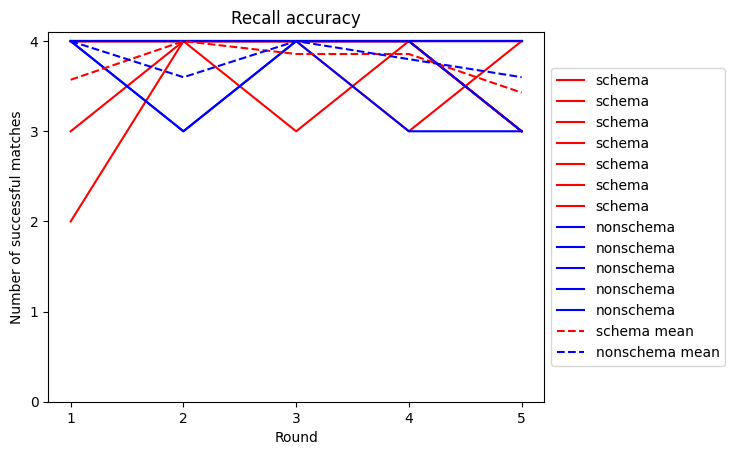

In [372]:
plt.plot(match_counts["schema"], c='red', label='schema')
plt.plot(match_counts["nonschema"], c='blue', label='nonschema')
plt.plot(match_counts["schema"].mean(axis=1), '--', c='red', label='schema mean')
plt.plot(match_counts["nonschema"].mean(axis=1), '--', c='blue', label='nonschema mean')
plt.ylim(0, 4.1)
plt.xlabel("Round")
plt.ylabel("Number of successful matches")
plt.yticks(range(5))
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))


plt.title("Recall accuracy")


Text(0.5, 1.0, 'Recall accuracy')

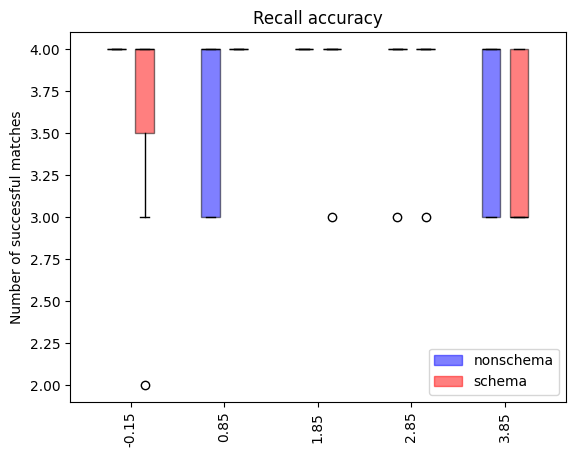

In [371]:
plt.boxplot(match_counts["nonschema"].T, positions=np.arange(0, len(labeling_stages))-.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='blue', alpha=.5), medianprops=dict(color='black'))
plt.boxplot(match_counts["schema"].T, positions=np.arange(0, len(labeling_stages))+.15, widths=0.2, patch_artist=True, boxprops=dict(facecolor='red', alpha=.5), medianprops=dict(color='black'))
plt.xticks(range(len(labeling_stages)), rotation=90)

import matplotlib.patches as mpatches

blue_patch = mpatches.Patch(color='blue', alpha=.5, label='nonschema')
red_patch = mpatches.Patch(color='red', alpha=.5, label='schema')

plt.legend(handles=[blue_patch, red_patch])
plt.ylabel('Number of successful matches')
plt.title("Recall accuracy")

In [370]:
match_counts["schema"]

game,5,6,7,8,9,10,11
round,,,,,,,
1,4,4,4,4,3,4,2
2,4,4,4,4,4,4,4
3,4,3,4,4,4,4,4
4,4,4,4,4,4,3,4
5,3,3,4,3,3,4,4
